<a href="https://colab.research.google.com/github/lawrancesahayasundar-tech/my_first_repo/blob/main/task1_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# task1_data_collection.py

"""
TrendPulse - Task 1: Data Collection

This script fetches trending stories from HackerNews API,
categorizes them based on keywords, and saves them into a JSON file.

Author: Lawrence
"""

import requests
import json
import os
import time
from datetime import datetime

# Base URLs for HackerNews API
TOP_STORIES_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL = "https://hacker-news.firebaseio.com/v0/item/{}.json"

# Custom header (as required)
HEADERS = {"User-Agent": "TrendPulse/1.0"}

# Category keyword mapping
CATEGORY_KEYWORDS = {
    "technology": ["ai", "software", "tech", "code", "computer", "data", "cloud", "api", "gpu", "llm"],
    "worldnews": ["war", "government", "country", "president", "election", "climate", "attack", "global"],
    "sports": ["nfl", "nba", "fifa", "sport", "game", "team", "player", "league", "championship"],
    "science": ["research", "study", "space", "physics", "biology", "discovery", "nasa", "genome"],
    "entertainment": ["movie", "film", "music", "netflix", "game", "book", "show", "award", "streaming"]
}

# Max stories per category
MAX_PER_CATEGORY = 25


def fetch_top_story_ids():
    """Fetch top story IDs from HackerNews"""
    try:
        response = requests.get(TOP_STORIES_URL, headers=HEADERS)
        response.raise_for_status()
        return response.json()[:500]  # first 500 IDs
    except Exception as e:
        print(f"Error fetching top stories: {e}")
        return []


def fetch_story(story_id):
    """Fetch individual story details"""
    try:
        url = ITEM_URL.format(story_id)
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Failed to fetch story {story_id}: {e}")
        return None


def categorize_title(title):
    """Assign category based on keywords"""
    if not title:
        return None

    title_lower = title.lower()

    for category, keywords in CATEGORY_KEYWORDS.items():
        for keyword in keywords:
            if keyword in title_lower:
                return category

    return None  # ignore if no match


def main():
    print("Fetching top stories...")

    story_ids = fetch_top_story_ids()
    collected_data = []

    # Track count per category
    category_counts = {cat: 0 for cat in CATEGORY_KEYWORDS}

    for category in CATEGORY_KEYWORDS:

        print(f"\nProcessing category: {category}")

        for story_id in story_ids:

            # Stop if category limit reached
            if category_counts[category] >= MAX_PER_CATEGORY:
                break

            story = fetch_story(story_id)

            if not story or "title" not in story:
                continue

            detected_category = categorize_title(story["title"])

            # Only collect if it matches current category
            if detected_category == category:

                record = {
                    "post_id": story.get("id"),
                    "title": story.get("title"),
                    "category": category,
                    "score": story.get("score", 0),
                    "num_comments": story.get("descendants", 0),
                    "author": story.get("by", "unknown"),
                    "collected_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                }

                collected_data.append(record)
                category_counts[category] += 1

        # Required delay between categories
        time.sleep(2)

    # Create data folder if not exists
    if not os.path.exists("data"):
        os.makedirs("data")

    # File name with date
    filename = f"data/trends_{datetime.now().strftime('%Y%m%d')}.json"

    # Save JSON
    with open(filename, "w") as f:
        json.dump(collected_data, f, indent=4)

    print(f"\nCollected {len(collected_data)} stories.")
    print(f"Saved to {filename}")


if __name__ == "__main__":
    main()

Fetching top stories...

Processing category: technology

Processing category: worldnews

Processing category: sports

Processing category: science

Processing category: entertainment

Collected 86 stories.
Saved to data/trends_20260417.json


In [2]:
# task2_data_processing.py

"""
TrendPulse - Task 2: Data Processing

This script loads the JSON file created in Task 1,
cleans the data, performs basic transformations,
and saves it as a CSV file.

Author: Lawrence
"""

import json
import pandas as pd
import os
from datetime import datetime


def get_latest_file():
    """
    Finds the latest trends JSON file from the data/ folder
    """
    folder = "data"

    if not os.path.exists(folder):
        print("Data folder not found. Run Task 1 first.")
        return None

    files = [f for f in os.listdir(folder) if f.startswith("trends_") and f.endswith(".json")]

    if not files:
        print("No JSON files found. Run Task 1 first.")
        return None

    files.sort(reverse=True)  # latest first
    return os.path.join(folder, files[0])


def load_data(filepath):
    """Load JSON data"""
    try:
        with open(filepath, "r") as f:
            data = json.load(f)
        return pd.DataFrame(data)
    except Exception as e:
        print(f"Error loading file: {e}")
        return None


def clean_data(df):
    """Perform data cleaning"""

    # Remove duplicates
    df = df.drop_duplicates(subset="post_id")

    # Handle missing values
    df["author"] = df["author"].fillna("unknown")
    df["score"] = df["score"].fillna(0)
    df["num_comments"] = df["num_comments"].fillna(0)

    # Convert data types
    df["score"] = df["score"].astype(int)
    df["num_comments"] = df["num_comments"].astype(int)

    # Convert collected_at to datetime
    df["collected_at"] = pd.to_datetime(df["collected_at"], errors="coerce")

    # Feature engineering: engagement score
    df["engagement"] = df["score"] + df["num_comments"]

    return df


def save_csv(df):
    """Save cleaned data to CSV"""
    filename = f"data/cleaned_trends_{datetime.now().strftime('%Y%m%d')}.csv"
    df.to_csv(filename, index=False)
    return filename


def main():
    print("Starting data processing...")

    filepath = get_latest_file()

    if not filepath:
        return

    print(f"Loading file: {filepath}")

    df = load_data(filepath)

    if df is None or df.empty:
        print("No data to process.")
        return

    print(f"Original records: {len(df)}")

    df = clean_data(df)

    print(f"Records after cleaning: {len(df)}")

    filename = save_csv(df)

    print(f"Cleaned data saved to {filename}")


if __name__ == "__main__":
    main()

Starting data processing...
Loading file: data/trends_20260417.json
Original records: 86
Records after cleaning: 86
Cleaned data saved to data/cleaned_trends_20260417.csv


In [3]:
# task3_analysis.py

"""
TrendPulse - Task 3: Data Analysis

This script loads the cleaned CSV file,
performs analysis using Pandas and NumPy,
and prints meaningful insights.

Author: Lawrence
"""

import pandas as pd
import numpy as np
import os


def get_latest_csv():
    """
    Finds the latest cleaned CSV file from data/ folder
    """
    folder = "data"

    if not os.path.exists(folder):
        print("Data folder not found. Run Task 2 first.")
        return None

    files = [f for f in os.listdir(folder) if f.startswith("cleaned_trends_") and f.endswith(".csv")]

    if not files:
        print("No cleaned CSV file found. Run Task 2 first.")
        return None

    files.sort(reverse=True)
    return os.path.join(folder, files[0])


def main():
    print("Starting analysis...")

    filepath = get_latest_csv()

    if not filepath:
        return

    print(f"Loading file: {filepath}")

    df = pd.read_csv(filepath)

    if df.empty:
        print("Dataset is empty.")
        return

    print("\nTotal Records:", len(df))

    # -----------------------------
    # 1. Category-wise count
    # -----------------------------
    print("\nCategory Distribution:")
    category_counts = df["category"].value_counts()
    print(category_counts)

    # -----------------------------
    # 2. Average score per category
    # -----------------------------
    print("\nAverage Score per Category:")
    avg_score = df.groupby("category")["score"].mean()
    print(avg_score)

    # -----------------------------
    # 3. Top 5 trending posts
    # -----------------------------
    print("\nTop 5 Trending Posts (by engagement):")
    top_posts = df.sort_values(by="engagement", ascending=False).head(5)
    print(top_posts[["title", "category", "engagement"]])

    # -----------------------------
    # 4. NumPy Analysis
    # -----------------------------
    print("\nNumPy Statistics:")

    scores = df["score"].values

    print("Max Score:", np.max(scores))
    print("Min Score:", np.min(scores))
    print("Mean Score:", np.mean(scores))
    print("Median Score:", np.median(scores))

    # -----------------------------
    # 5. Most active authors
    # -----------------------------
    print("\nTop 5 Active Authors:")
    top_authors = df["author"].value_counts().head(5)
    print(top_authors)

    print("\nAnalysis completed successfully.")


if __name__ == "__main__":
    main()

Starting analysis...
Loading file: data/cleaned_trends_20260417.csv

Total Records: 86

Category Distribution:
category
technology       25
entertainment    25
worldnews        19
sports           10
science           7
Name: count, dtype: int64

Average Score per Category:
category
entertainment     65.960000
science           61.000000
sports            87.600000
technology       188.200000
worldnews         44.631579
Name: score, dtype: float64

Top 5 Trending Posts (by engagement):
                                                title       category  \
0                         Codex for almost everything     technology   
77  Show HN: boringBar – a taskbar-style dock repl...  entertainment   
46  Nothing Ever Happens: Polymarket bot that alwa...         sports   
20  €54k spike in 13h from unrestricted Firebase b...     technology   
12                           Cloudflare Email Service     technology   

    engagement  
0         1189  
77         819  
46         740  
20      

Starting visualization...
Loading file: data/cleaned_trends_20260417.csv


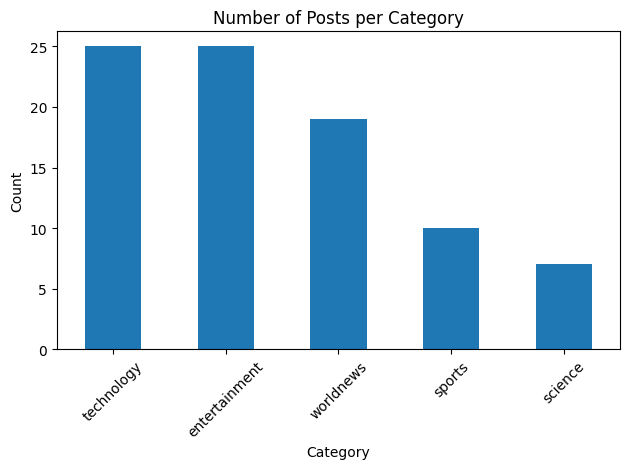

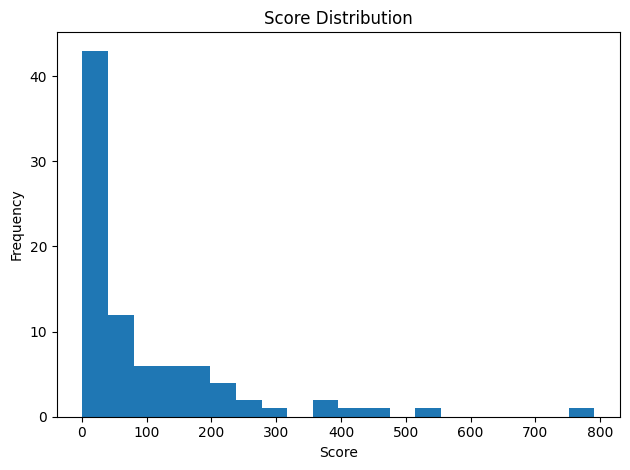

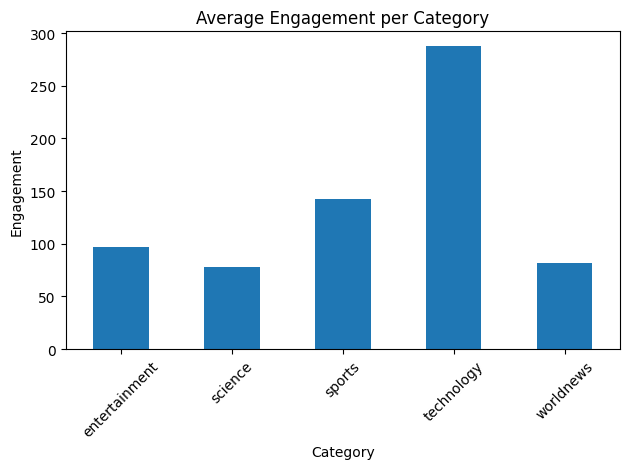

/tmp/ipykernel_3432/4230677716.py:98: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


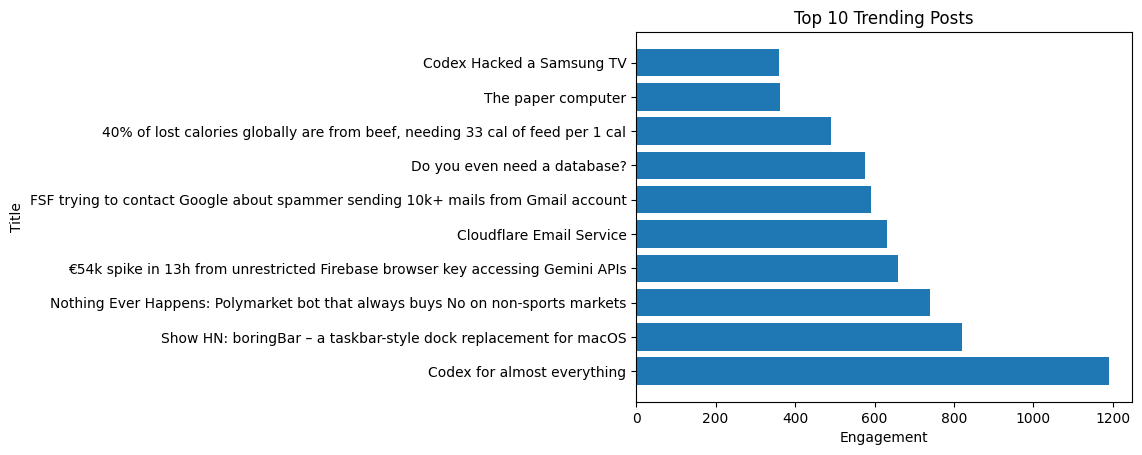

Visualization completed successfully.


In [4]:
# task4_visualization.py

"""
TrendPulse - Task 4: Data Visualization

This script loads the cleaned CSV file
and creates visualizations to understand trends.

Author: Lawrence
"""

import pandas as pd
import matplotlib.pyplot as plt
import os


def get_latest_csv():
    """
    Finds the latest cleaned CSV file from data/ folder
    """
    folder = "data"

    if not os.path.exists(folder):
        print("Data folder not found. Run Task 2 first.")
        return None

    files = [f for f in os.listdir(folder) if f.startswith("cleaned_trends_") and f.endswith(".csv")]

    if not files:
        print("No cleaned CSV file found.")
        return None

    files.sort(reverse=True)
    return os.path.join(folder, files[0])


def main():
    print("Starting visualization...")

    filepath = get_latest_csv()

    if not filepath:
        return

    print(f"Loading file: {filepath}")

    df = pd.read_csv(filepath)

    if df.empty:
        print("Dataset is empty.")
        return

    # -----------------------------
    # 1. Category Distribution (Bar Chart)
    # -----------------------------
    plt.figure()
    df["category"].value_counts().plot(kind="bar")
    plt.title("Number of Posts per Category")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 2. Score Distribution (Histogram)
    # -----------------------------
    plt.figure()
    df["score"].plot(kind="hist", bins=20)
    plt.title("Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 3. Engagement by Category (Bar Chart)
    # -----------------------------
    plt.figure()
    df.groupby("category")["engagement"].mean().plot(kind="bar")
    plt.title("Average Engagement per Category")
    plt.xlabel("Category")
    plt.ylabel("Engagement")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 4. Top 10 Posts (Horizontal Bar)
    # -----------------------------
    top_posts = df.sort_values(by="engagement", ascending=False).head(10)

    plt.figure()
    plt.barh(top_posts["title"], top_posts["engagement"])
    plt.title("Top 10 Trending Posts")
    plt.xlabel("Engagement")
    plt.ylabel("Title")
    plt.tight_layout()
    plt.show()

    print("Visualization completed successfully.")


if __name__ == "__main__":
    main()